# 03 — Implied Volatility Surface (H2) and Smile Calibration (H4)

**H2 (volatility smile).** The market-implied volatility surface (SPY and
AAPL) exhibits skew/smile inconsistent with Black-Scholes' constant-
volatility assumption.
- H0: implied vol is flat across strikes at fixed maturity
- H1: implied vol varies systematically with moneyness
- Test: OLS of IV on log-moneyness (linear + quadratic) per expiry, test
  slope/curvature != 0

**H4 (model improvement over BS).** Heston and/or Merton jump-diffusion,
calibrated to the same implied-vol surface, achieve lower calibration RMSE
than Black-Scholes with a single flat vol, indicating the smile reflects
priced risk rather than noise.
- H0: added complexity does not materially reduce calibration error
- H1: RMSE drops materially and survives an out-of-sample check on held-out
  strikes

We use our own Brent-solved implied vols throughout (`src/implied_vol.py`),
not OptionMetrics's own IV field -- see notebook 01 EDA for why that field is
unreliable at the tails.

In [1]:
import sys, warnings, time
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")  # numerical warnings from infeasible
                                     # candidate prices explored mid-optimization
                                     # are expected and handled (see implied_vol.py);
                                     # silenced here only for notebook readability

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from data_loader import latest_pull
from implied_vol import add_implied_vol, solve_implied_vol
from black_scholes import bs_price
from merton_jump import calibrate_merton, merton_jump_price
from heston import calibrate_heston, heston_price
from evaluation import iv_rmse

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

data = {}
for tkr in ["SPY", "AAPL"]:
    summary, df = latest_pull(tkr)
    out, iv_report = add_implied_vol(df)
    data[tkr] = {"summary": summary, "df": out, "iv_report": iv_report}
    print(tkr, iv_report)

SPY {'n_total': 651, 'n_success': 651, 'n_failed': 0, 'pct_success': 100.0, 'n_brent': 651, 'n_newton_fallback': 0}


AAPL {'n_total': 102, 'n_success': 100, 'n_failed': 2, 'pct_success': 98.0, 'n_brent': 100, 'n_newton_fallback': 0}


## H2 — smile regression: IV ~ log-moneyness + log-moneyness^2

One caveat up front: each per-expiry regression below treats every strike
as an independent observation, but adjacent strikes on the same
underlying, same day, share overlapping market-microstructure noise (a
spot tick affects every quote at once), so the effective sample size is
smaller than the raw strike count and plain OLS p-values are almost
certainly optimistic. Standard practice for this kind of smile regression
(and what's reported here) is plain OLS *and* Newey-West HAC-robust
standard errors ordered along the moneyness axis, which is the natural
ordering for the correlation this induces. If a coefficient is significant
under HAC too, that's a much stronger claim than the OLS p-value alone.

In [2]:
h2_rows = []
for tkr, d in data.items():
    out = d["df"]
    valid = out[out.iv_success]
    for expiry, grp in valid.groupby("expiry"):
        grp = grp.sort_values("log_moneyness")  # HAC needs a meaningful order
        X = sm.add_constant(pd.DataFrame({"lm": grp.log_moneyness, "lm2": grp.log_moneyness ** 2}))
        y = grp.iv_computed
        model = sm.OLS(y, X).fit()
        model_hac = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": max(1, len(grp) // 20)})
        h2_rows.append({
            "ticker": tkr, "expiry": expiry, "n": len(grp),
            "linear_coef": model.params["lm"], "linear_p_ols": model.pvalues["lm"],
            "linear_p_hac": model_hac.pvalues["lm"],
            "curvature_coef": model.params["lm2"], "curvature_p_ols": model.pvalues["lm2"],
            "curvature_p_hac": model_hac.pvalues["lm2"],
            "R2": model.rsquared,
        })
h2_df = pd.DataFrame(h2_rows)
h2_df

,ticker,expiry,n,linear_coef,linear_p_ols,linear_p_hac,curvature_coef,curvature_p_ols,curvature_p_hac,R2
0,SPY,2024-04-05,157,-0.616106,1.622932e-34,2.412617e-06,1.715254,5.451169e-21,1.550753e-03,0.937543
1,SPY,2024-04-30,288,-0.539828,2.493642e-51,6.167711e-10,1.247064,2.052238e-26,5.337914e-05,0.917507
2,SPY,2024-07-19,206,-0.313815,1.409509e-82,8.572670e-38,0.811890,2.616837e-54,2.014529e-15,0.951432
3,AAPL,2024-04-05,28,-0.149280,3.484350e-04,7.525545e-06,2.453182,4.784758e-14,2.282794e-38,0.961457
4,AAPL,2024-04-26,26,-0.141256,2.663955e-05,2.456104e-05,1.994374,1.719347e-12,2.171199e-17,0.941290
5,AAPL,2024-07-19,46,-0.120846,8.210434e-14,6.786725e-68,0.508421,3.100396e-12,1.852389e-92,0.820867


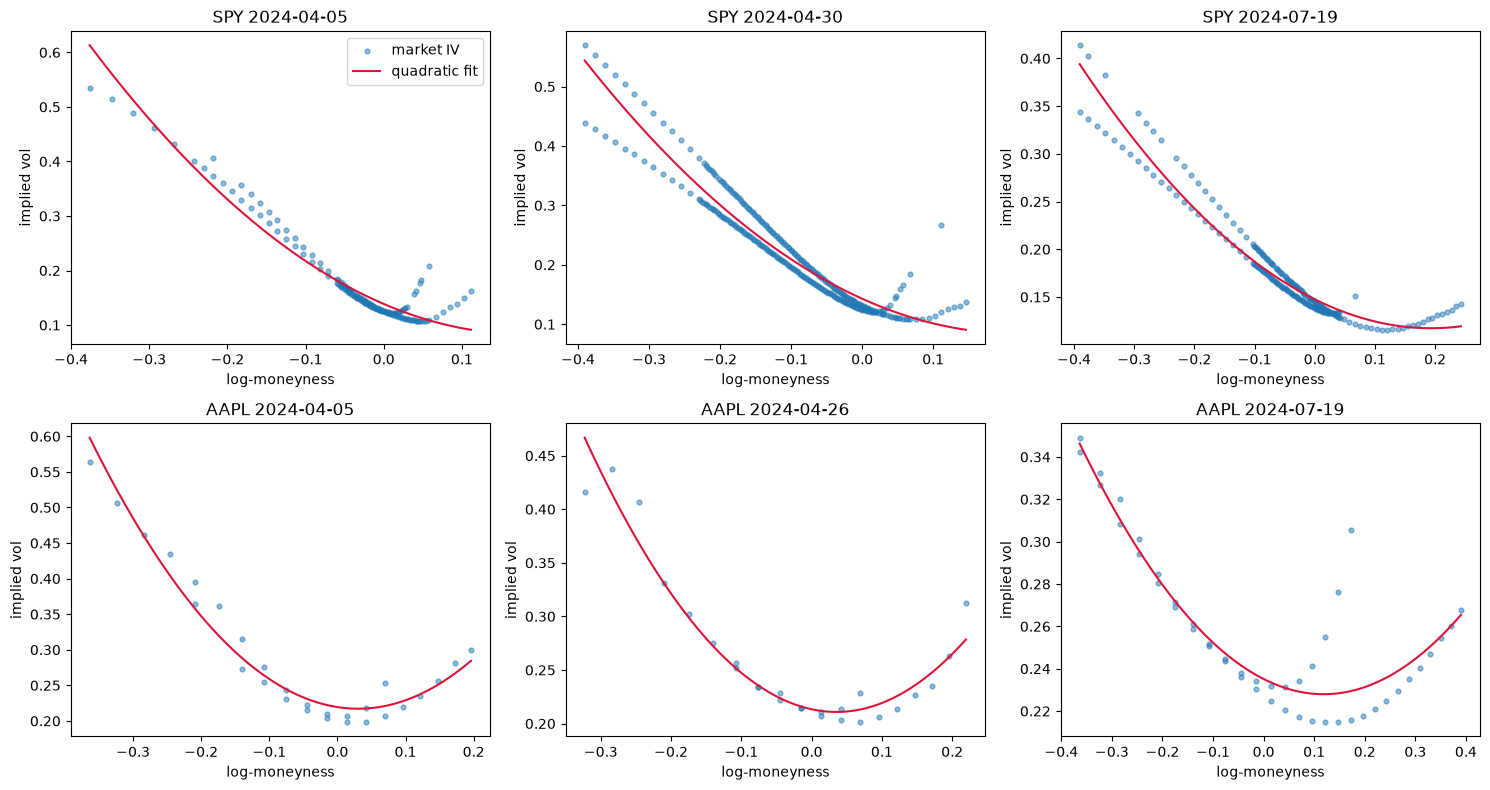

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
for row, tkr in enumerate(["SPY", "AAPL"]):
    valid = data[tkr]["df"]
    valid = valid[valid.iv_success]
    for col, (expiry, grp) in enumerate(valid.groupby("expiry")):
        ax = axes[row, col]
        ax.scatter(grp.log_moneyness, grp.iv_computed, s=12, alpha=0.5, label="market IV")

        X = sm.add_constant(pd.DataFrame({"lm": grp.log_moneyness, "lm2": grp.log_moneyness ** 2}))
        fit = sm.OLS(grp.iv_computed, X).fit()
        lm_grid = np.linspace(grp.log_moneyness.min(), grp.log_moneyness.max(), 100)
        X_grid = sm.add_constant(pd.DataFrame({"lm": lm_grid, "lm2": lm_grid ** 2}))
        fitted_iv = fit.predict(X_grid)
        ax.plot(lm_grid, fitted_iv, color="crimson", label="quadratic fit")

        ax.set_title(f"{tkr} {expiry}")
        ax.set_xlabel("log-moneyness")
        ax.set_ylabel("implied vol")
        if row == 0 and col == 0:
            ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/h2_smile_scatter.png", dpi=120)
plt.show()

In [4]:
print("max OLS p-value (linear):", h2_df.linear_p_ols.max())
print("max OLS p-value (curvature):", h2_df.curvature_p_ols.max())
print("max HAC p-value (linear):", h2_df.linear_p_hac.max())
print("max HAC p-value (curvature):", h2_df.curvature_p_hac.max())

max OLS p-value (linear): 0.00034843500174006303
max OLS p-value (curvature): 3.1003959231650538e-12
max HAC p-value (linear): 2.456103826586627e-05
max HAC p-value (curvature): 0.0015507528733971156


Read the verdict off the printed max p-values above, not assumed in
advance: if both the OLS and HAC-robust max p-values stay small, H0 (flat
IV) is rejected under both the naive and the correlation-robust test, which
is the stronger of the two claims worth making. If HAC p-values are
noticeably larger than OLS (expected, since HAC is more conservative) but
still small, that's the honest version of "H2 is supported."

## H4 — Merton and Heston calibration with out-of-sample check

Design choice: rather than calibrating to every surviving call in the
chain (100-250 per expiry), we calibrate to a **curated subsample of 12
strikes evenly spaced across the moneyness range actually present**. Two
reasons: (1) adjacent strikes carry highly redundant information and cost
is dominated by the per-point implied-vol solve inside the calibration
objective, so using all of them mostly adds runtime, not information; (2)
it gives a clean, honest in-sample/out-of-sample split -- every remaining
valid call at that expiry becomes a **held-out** test point never seen
during calibration. Calls only, to avoid put/call redundancy from
put-call parity.

Both calibrators run from **3 starting points** (one fixed, two randomized
within a reasonable domain, see `src/heston.py` / `src/merton_jump.py`)
and keep the best by RMSE. Both SLSQP (Heston, constrained) and L-BFGS-B
(Merton) are local optimizers on non-convex objectives, so a single start
can't distinguish "this data doesn't identify the model" from "this
particular starting point found a mediocre local optimum." The spread
across the 3 attempts (`*_start_rmse_spread` below) makes that visible
instead of hiding it.

In [5]:
def calibration_split(df_expiry, n_calib=12):
    calls = df_expiry[(df_expiry.iv_success) & (df_expiry.option_type == "call")].sort_values("strike")
    n_calib = min(n_calib, max(4, len(calls) // 2))
    idx = np.unique(np.linspace(0, len(calls) - 1, n_calib).astype(int))
    calib = calls.iloc[idx]
    holdout = calls.drop(calls.index[idx])
    return calib, holdout


def bs_flat_iv_rmse(calib, holdout, spot):
    # BS "single flat vol" baseline: ATM implied vol from the calibration
    # set, applied as a constant prediction across all strikes.
    atm_iv = calib.iloc[(calib.strike - spot).abs().argsort().iloc[0]].iv_computed
    is_rmse = iv_rmse(np.full(len(calib), atm_iv), calib.iv_computed.values)
    oos_rmse = iv_rmse(np.full(len(holdout), atm_iv), holdout.iv_computed.values) if len(holdout) else np.nan
    return atm_iv, is_rmse, oos_rmse


def model_iv_rmse(price_fn, calib, holdout, spot, r, q):
    def evaluate(subset):
        model_ivs = []
        for _, row in subset.iterrows():
            price = price_fn(spot, row.strike, row.T_years)
            res = solve_implied_vol(price, spot, row.strike, r, q, row.T_years, "call")
            model_ivs.append(res["iv"] if res["success"] else np.nan)
        model_ivs = np.array(model_ivs)
        mkt = subset.iv_computed.values
        mask = ~np.isnan(model_ivs)
        return iv_rmse(model_ivs[mask], mkt[mask]), mask.sum(), len(subset)
    is_rmse, is_n, is_total = evaluate(calib)
    oos_rmse, oos_n, oos_total = evaluate(holdout) if len(holdout) else (np.nan, 0, 0)
    return is_rmse, oos_rmse, (is_n, is_total), (oos_n, oos_total)

In [6]:
h4_rows = []
merton_params = {}
heston_params = {}

for tkr, d in data.items():
    summary, df = d["summary"], d["df"]
    spot = summary["spot"]
    r = summary["risk_free_rate"]["r_cc"]
    q = summary["dividend_yield"]["q_used"]

    for expiry, grp in df.groupby("expiry"):
        calib, holdout = calibration_split(grp, n_calib=12)
        if len(calib) < 6:
            print(f"SKIP {tkr} {expiry}: only {len(calib)} valid calls, too few to calibrate")
            continue

        t0 = time.time()
        m_res = calibrate_merton(calib, spot, r, q, n_starts=3)
        m_time = time.time() - t0
        merton_params[(tkr, expiry)] = m_res

        t0 = time.time()
        h_res = calibrate_heston(calib, spot, r, q, x0=[3.0, 0.03, 0.6, -0.6, 0.03],
                                  enforce_feller=True, maxiter=200, n_starts=3)
        h_time = time.time() - t0
        heston_params[(tkr, expiry)] = h_res

        atm_iv, bs_is, bs_oos = bs_flat_iv_rmse(calib, holdout, spot)

        merton_price_fn = lambda S, K, T, p=m_res: merton_jump_price(
            S, K, r, q, p["sigma"], T, p["lam"], p["mu_j"], p["sigma_j"], "call")[0]
        m_is, m_oos, m_is_n, m_oos_n = model_iv_rmse(merton_price_fn, calib, holdout, spot, r, q)

        heston_price_fn = lambda S, K, T, p=h_res: heston_price(
            S, K, r, q, T, p["kappa"], p["theta"], p["xi"], p["rho"], p["v0"], "call")
        h_is, h_oos, h_is_n, h_oos_n = model_iv_rmse(heston_price_fn, calib, holdout, spot, r, q)

        h4_rows.append({
            "ticker": tkr, "expiry": expiry, "n_calib": len(calib), "n_holdout": len(holdout),
            "BS_flat_IV": atm_iv, "BS_is_rmse": bs_is, "BS_oos_rmse": bs_oos,
            "Merton_is_rmse": m_is, "Merton_oos_rmse": m_oos, "Merton_success": m_res["success"],
            "Merton_time_s": round(m_time, 1),
            "Merton_start_rmse_spread": max(m_res["all_start_rmse"]) - min(m_res["all_start_rmse"]),
            "Heston_is_rmse": h_is, "Heston_oos_rmse": h_oos, "Heston_success": h_res["success"],
            "Heston_feller_ok": h_res["feller_satisfied"], "Heston_time_s": round(h_time, 1),
            "Heston_start_rmse_spread": max(h_res["all_start_rmse"]) - min(h_res["all_start_rmse"]),
        })
        print(f"done {tkr} {expiry}: BS oos={bs_oos:.4f} Merton oos={m_oos:.4f} Heston oos={h_oos:.4f}")

h4_df = pd.DataFrame(h4_rows)
h4_df

done SPY 2024-04-05: BS oos=0.0649 Merton oos=0.0074 Heston oos=0.0201


done SPY 2024-04-30: BS oos=0.1386 Merton oos=0.0082 Heston oos=0.0452


done SPY 2024-07-19: BS oos=0.0644 Merton oos=0.0051 Heston oos=0.0275


done AAPL 2024-04-05: BS oos=0.0499 Merton oos=0.0082 Heston oos=0.0142


done AAPL 2024-04-26: BS oos=0.0262 Merton oos=0.0113 Heston oos=0.0151


done AAPL 2024-07-19: BS oos=0.0412 Merton oos=0.0022 Heston oos=0.0066


,ticker,expiry,n_calib,n_holdout,BS_flat_IV,BS_is_rmse,BS_oos_rmse,Merton_is_rmse,Merton_oos_rmse,Merton_success,Merton_time_s,Merton_start_rmse_spread,Heston_is_rmse,Heston_oos_rmse,Heston_success,Heston_feller_ok,Heston_time_s,Heston_start_rmse_spread
0,SPY,2024-04-05,12,67,0.127684,0.091947,0.064889,0.007341,0.007444,True,28.8,2.849490e-08,0.013491,0.020122,True,True,73.8,3.023247e-02
1,SPY,2024-04-30,12,137,0.140257,0.163351,0.138632,0.010039,0.008159,True,41.2,8.227978e-09,0.056721,0.045168,False,False,187.4,1.373168e-02
2,SPY,2024-07-19,12,100,0.149389,0.087297,0.064430,0.005047,0.005105,True,40.6,1.207001e-08,0.038546,0.027543,True,False,112.9,2.860840e-10
3,AAPL,2024-04-05,7,7,0.198107,0.078273,0.049902,0.002576,0.008204,True,15.2,1.293178e-05,0.019390,0.014183,True,False,30.7,6.177685e-03
4,AAPL,2024-04-26,6,7,0.207089,0.049064,0.026189,0.006806,0.011334,True,19.6,2.997816e-02,0.020785,0.015134,True,False,34.3,6.268964e-04
5,AAPL,2024-07-19,12,16,0.220459,0.054022,0.041237,0.002171,0.002155,True,38.6,1.427388e-07,0.008414,0.006608,True,False,134.1,8.294787e-11


## H4 verdict table (out-of-sample RMSE improvement vs. flat BS)

In [7]:
verdict = h4_df.copy()
verdict["Merton_oos_improves_pct"] = 100 * (verdict.BS_oos_rmse - verdict.Merton_oos_rmse) / verdict.BS_oos_rmse
verdict["Heston_oos_improves_pct"] = 100 * (verdict.BS_oos_rmse - verdict.Heston_oos_rmse) / verdict.BS_oos_rmse
verdict[["ticker", "expiry", "n_calib", "n_holdout", "BS_oos_rmse",
         "Merton_oos_rmse", "Merton_oos_improves_pct", "Merton_success",
         "Heston_oos_rmse", "Heston_oos_improves_pct", "Heston_success", "Heston_feller_ok"]]

,ticker,expiry,n_calib,n_holdout,BS_oos_rmse,Merton_oos_rmse,Merton_oos_improves_pct,Merton_success,Heston_oos_rmse,Heston_oos_improves_pct,Heston_success,Heston_feller_ok
0,SPY,2024-04-05,12,67,0.064889,0.007444,88.528799,True,0.020122,68.989552,True,True
1,SPY,2024-04-30,12,137,0.138632,0.008159,94.114893,True,0.045168,67.419134,False,False
2,SPY,2024-07-19,12,100,0.064430,0.005105,92.076757,True,0.027543,57.250535,True,False
3,AAPL,2024-04-05,7,7,0.049902,0.008204,83.559364,True,0.014183,71.578438,True,False
4,AAPL,2024-04-26,6,7,0.026189,0.011334,56.723656,True,0.015134,42.211758,True,False
5,AAPL,2024-07-19,12,16,0.041237,0.002155,94.775160,True,0.006608,83.975812,True,False


## Calibrated parameters

In [8]:
param_rows = []
for (tkr, expiry), p in merton_params.items():
    param_rows.append({"ticker": tkr, "expiry": expiry, "model": "Merton",
                        "params": f"sigma={p['sigma']:.3f}, lam={p['lam']:.3f}, "
                                  f"mu_j={p['mu_j']:.3f}, sigma_j={p['sigma_j']:.3f}",
                        "success": p["success"], "rmse_iv": p["final_rmse_iv"],
                        "start_rmse_spread": max(p["all_start_rmse"]) - min(p["all_start_rmse"])})
for (tkr, expiry), p in heston_params.items():
    param_rows.append({"ticker": tkr, "expiry": expiry, "model": "Heston",
                        "params": f"kappa={p['kappa']:.3f}, theta={p['theta']:.3f}, "
                                  f"xi={p['xi']:.3f}, rho={p['rho']:.3f}, v0={p['v0']:.3f}",
                        "success": p["success"], "rmse_iv": p["final_rmse_iv"],
                        "feller_ok": p["feller_satisfied"],
                        "start_rmse_spread": max(p["all_start_rmse"]) - min(p["all_start_rmse"])})
pd.DataFrame(param_rows)

,ticker,expiry,model,params,success,rmse_iv,start_rmse_spread,feller_ok
0,SPY,2024-04-05,Merton,"sigma=0.110, lam=0.286, mu_j=-0.154, sigma_j=0...",True,0.007341,2.849490e-08,NaN
1,SPY,2024-04-30,Merton,"sigma=0.113, lam=0.095, mu_j=-0.500, sigma_j=0...",True,0.010039,8.227978e-09,NaN
2,SPY,2024-07-19,Merton,"sigma=0.109, lam=0.110, mu_j=-0.500, sigma_j=0...",True,0.005047,1.207001e-08,NaN
3,AAPL,2024-04-05,Merton,"sigma=0.190, lam=0.518, mu_j=-0.048, sigma_j=0...",True,0.002576,1.293178e-05,NaN
4,AAPL,2024-04-26,Merton,"sigma=0.189, lam=0.094, mu_j=-0.500, sigma_j=0...",True,0.006806,2.997816e-02,NaN
5,AAPL,2024-07-19,Merton,"sigma=0.185, lam=0.387, mu_j=-0.142, sigma_j=0...",True,0.002171,1.427388e-07,NaN
6,SPY,2024-04-05,Heston,"kappa=7.805, theta=0.094, xi=1.210, rho=-0.781...",True,0.012316,3.023247e-02,True
7,SPY,2024-04-30,Heston,"kappa=0.208, theta=1.904, xi=0.891, rho=-0.990...",False,0.054306,1.373168e-02,False
8,SPY,2024-07-19,Heston,"kappa=0.095, theta=2.000, xi=0.618, rho=-0.847...",True,0.038546,2.860840e-10,False
9,AAPL,2024-04-05,Heston,"kappa=2.973, theta=0.616, xi=1.914, rho=-0.213...",True,0.019390,6.177685e-03,False


## Parameter stability check

Refit Merton and Heston on an alternate calibration subset (offset by one
index in the strike grid, so different but overlapping strikes) for one
representative ticker/expiry, and compare parameters. Large swings would
indicate weak identification from this data (a real possibility with
jump/vol-of-vol parameters, especially with only 12 calibration points).

In [9]:
stability_tkr, stability_expiry = "SPY", data["SPY"]["df"].expiry.unique()[1]  # mid-dated expiry
grp = data["SPY"]["df"][data["SPY"]["df"].expiry == stability_expiry]
calls_all = grp[(grp.iv_success) & (grp.option_type == "call")].sort_values("strike").reset_index(drop=True)

idx_a = np.unique(np.linspace(0, len(calls_all) - 1, 12).astype(int))
idx_b = np.unique(np.linspace(1, len(calls_all) - 2, 12).astype(int)) if len(calls_all) > 14 else idx_a
calib_a = calls_all.iloc[idx_a]
calib_b = calls_all.iloc[idx_b]

spot = data["SPY"]["summary"]["spot"]
r = data["SPY"]["summary"]["risk_free_rate"]["r_cc"]
q = data["SPY"]["summary"]["dividend_yield"]["q_used"]

merton_a = calibrate_merton(calib_a, spot, r, q, n_starts=3)
merton_b = calibrate_merton(calib_b, spot, r, q, n_starts=3)
heston_a = calibrate_heston(calib_a, spot, r, q, x0=[3.0, 0.03, 0.6, -0.6, 0.03], enforce_feller=True, maxiter=200, n_starts=3)
heston_b = calibrate_heston(calib_b, spot, r, q, x0=[3.0, 0.03, 0.6, -0.6, 0.03], enforce_feller=True, maxiter=200, n_starts=3)

stability_df = pd.DataFrame([
    {"model": "Merton", "param": "sigma", "subset_A": merton_a["sigma"], "subset_B": merton_b["sigma"]},
    {"model": "Merton", "param": "lam", "subset_A": merton_a["lam"], "subset_B": merton_b["lam"]},
    {"model": "Merton", "param": "mu_j", "subset_A": merton_a["mu_j"], "subset_B": merton_b["mu_j"]},
    {"model": "Merton", "param": "sigma_j", "subset_A": merton_a["sigma_j"], "subset_B": merton_b["sigma_j"]},
    {"model": "Heston", "param": "kappa", "subset_A": heston_a["kappa"], "subset_B": heston_b["kappa"]},
    {"model": "Heston", "param": "theta", "subset_A": heston_a["theta"], "subset_B": heston_b["theta"]},
    {"model": "Heston", "param": "xi", "subset_A": heston_a["xi"], "subset_B": heston_b["xi"]},
    {"model": "Heston", "param": "rho", "subset_A": heston_a["rho"], "subset_B": heston_b["rho"]},
    {"model": "Heston", "param": "v0", "subset_A": heston_a["v0"], "subset_B": heston_b["v0"]},
])
stability_df["pct_change"] = 100 * (stability_df.subset_B - stability_df.subset_A) / stability_df.subset_A.abs()
print(f"Stability check on {stability_tkr} {stability_expiry}")
stability_df

Stability check on SPY 2024-04-30


,model,param,subset_A,subset_B,pct_change
0,Merton,sigma,0.112748,0.112931,1.623290e-01
1,Merton,lam,0.095324,0.094861,-4.855593e-01
2,Merton,mu_j,-0.500000,-0.500000,0.000000e+00
3,Merton,sigma_j,0.323422,0.313435,-3.087936e+00
4,Heston,kappa,0.208487,0.281434,3.498858e+01
5,Heston,theta,1.904260,2.000000,5.027648e+00
6,Heston,xi,0.891195,1.061008,1.905451e+01
7,Heston,rho,-0.990000,-0.990000,-4.306320e-12
8,Heston,v0,0.001000,0.001000,-6.216815e-11


## Persist results for the report

In [10]:
h2_df.to_csv("../results/tables/h2_smile_regression.csv", index=False)
h4_df.to_csv("../results/tables/h4_calibration_verdict.csv", index=False)
pd.DataFrame(param_rows).to_csv("../results/tables/h4_calibrated_params.csv", index=False)
stability_df.to_csv("../results/tables/h4_parameter_stability_same_maturity.csv", index=False)
print("saved h2/h4 tables to results/tables/")

saved h2/h4 tables to results/tables/


## Summary

See the verdict table above for the per-expiry, per-ticker out-of-sample
comparison. Read the improvement percentages directly rather than assuming
either model wins uniformly -- the whole point of the out-of-sample check
is that it's allowed to say no. Interpretation of the actual numbers,
including any cases where Heston underperforms Merton on short-dated
expiries (consistent with short-dated skew being more jump- than
diffusion-driven) or where a calibration doesn't converge / violates the
Feller condition, belongs in `report/report.md`, written from these
computed results rather than assumed in advance.